# AI 201 - Programming Assignment 2
## Naive Bayes Spam Filter

**Instructor:** Prospero C. Naval, Jr., Ph.D.  
**Due Date:** 12:00 noon, March 13, 2026     
**Semester:** 2nd Semester, AY 2025–2026

**Author:** Adriane Jone A. Abunda

## Naive Bayes for the TREC06 Corpus

In [1]:
# Import and setup
import random
import re
import math
import matplotlib.pyplot as plt
import os
import csv

def load_and_split_data(filename, split_ratio=0.7):
    """Loads data from a file and splits it into training and testing sets."""
    with open(filename, 'r') as f:
        lines = f.readlines()

    data = []
    for line in lines:
        if line.strip():
            label, raw_path = line.strip().split()
            if raw_path.startswith('../'):
                clean_path = raw_path.replace('../', '', 1)
            else:
                clean_path = raw_path
            data.append((label, clean_path))

    random.seed(42)
    random.shuffle(data)

    split_index = int(len(data) * split_ratio)
    train_data = data[:split_index]
    test_data  = data[split_index:]

    def save_split(split, filename):
        with open(filename, 'w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(['label', 'filepath'])
            writer.writerows(split)

    save_split(train_data, 'train_set.csv')
    save_split(test_data,  'test_set.csv')
    print(f"Saved train_set.csv ({len(train_data)} rows) and "
          f"test_set.csv ({len(test_data)} rows)")

    return train_data, test_data

In [2]:
# 2.1: Classifier Construction and Evaluation

def parse_document(filepath):
    """Parses a document into a set of unique words"""
    filepath = os.path.normpath(filepath) 
    with open(filepath, 'r', encoding='Latin-1') as f:
        text = f.read()
    text = " " + text + " "
    pattern = r'(?<=\s)[a-zA-Z]+(?=[\s,\.])'
    words = re.findall(pattern, text)
    unique_words = set(word.lower() for word in words)
    return unique_words

def build_statistics(train_data):
    N_spam = 0
    N_ham = 0
    spam_word_counts = {}
    ham_word_counts = {}
    vocabulary = set()
    
    for label, filepath in train_data:
        words = parse_document(filepath)
        vocabulary.update(words)
        
        if label == 'spam':
            N_spam += 1
            for word in words:
                spam_word_counts[word] = spam_word_counts.get(word, 0) + 1
        else:
            N_ham += 1
            for word in words:
                ham_word_counts[word] = ham_word_counts.get(word, 0) + 1
        
    total_docs = N_spam + N_ham
    prior_spam = N_spam / total_docs if total_docs > 0 else 0
    prior_ham = N_ham / total_docs if total_docs > 0 else 0
    return vocabulary, spam_word_counts, ham_word_counts, N_spam, N_ham, prior_spam, prior_ham

def classify_message(filepath, vocabulary, spam_word_counts, ham_word_counts, N_spam, N_ham, prior_spam, prior_ham):
    """Classifies a message using the base Naive Bayes formula (no smoothing)."""
    words = parse_document(filepath)
    spam_score = math.log(prior_spam) if prior_spam > 0 else float('-inf')
    ham_score = math.log(prior_ham) if prior_ham > 0 else float('-inf')
    
    for word in words:
        if word not in vocabulary:
            continue
        
        count_spam = spam_word_counts.get(word, 0)
        if count_spam > 0:
            spam_score += math.log(count_spam / N_spam)
        else:
            spam_score = float('-inf')
        
        count_ham = ham_word_counts.get(word, 0)
        if count_ham > 0:
            ham_score += math.log(count_ham / N_ham)
        else:
            ham_score = float('-inf')
    
    if spam_score > ham_score:
        return 'spam'
    else:
        return 'ham'

# 2.2: Lambda Smoothing

def classify_message_smoothed(filepath, vocabulary, spam_word_counts, ham_word_counts, N_spam, N_ham, prior_spam, prior_ham, smoothing_factor=1.0):
    """Classifies a message using Lambda Smoothing."""
    words = parse_document(filepath)
    spam_score = math.log(prior_spam) if prior_spam > 0 else float('-inf')
    ham_score = math.log(prior_ham) if prior_ham > 0 else float('-inf')
    vocab_size = len(vocabulary)
    denom_spam = N_spam + (smoothing_factor * vocab_size)
    denom_ham = N_ham + (smoothing_factor * vocab_size)
    
    for word in words:
        if word not in vocabulary:
            continue
        # P(word|spam) with smoothing
        num_spam = spam_word_counts.get(word, 0) + smoothing_factor
        prob_spam = num_spam / denom_spam
        spam_score += math.log(prob_spam)
        
        # P(word|ham) with smoothing
        num_ham = ham_word_counts.get(word, 0) + smoothing_factor
        prob_ham = num_ham / denom_ham
        ham_score += math.log(prob_ham)
    
    if spam_score > ham_score:
        return 'spam'
    else:
        return 'ham'

def plot_confusion_matrix(tp, tn, fp, fn, title='Confusion Matrix'):
    """Plots a 2x2 confusion matrix using matplotlib."""
    matrix = [[tn, fp], 
              [fn, tp]]
    
    fig, ax = plt.subplots(figsize=(5, 5))
    im = ax.imshow(matrix, cmap='Blues')
    
    labels = [['TN', 'FP'], ['FN', 'TP']]
    for i in range(2):
        for j in range(2):
            text = ax.text(j, i, f"{labels[i][j]}\n{matrix[i][j]}", ha="center", va="center", color="black", fontsize=12)

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Predicted HAM', 'Predicted SPAM'])
    ax.set_yticklabels(['Actual HAM', 'Actual SPAM'])
    ax.set_title(title)
    plt.show()
    
def evaluate_classifier(test_data, vocabulary, spam_word_counts, ham_word_counts, N_spam, N_ham, prior_spam, prior_ham, smoothing_factor=None):
    true_positives = 0
    true_negatives = 0
    false_positives = 0
    false_negatives = 0
    
    for label, filepath in test_data:
        if smoothing_factor is not None:
            predicted = classify_message_smoothed(filepath, vocabulary, spam_word_counts, ham_word_counts, N_spam, N_ham, prior_spam, prior_ham, smoothing_factor)
        else:
            predicted = classify_message(filepath, vocabulary, spam_word_counts, ham_word_counts, N_spam, N_ham, prior_spam, prior_ham)
        
        if predicted == 'spam' and label == 'spam':
            true_positives += 1
        elif predicted == 'ham' and label == 'ham':
            true_negatives += 1
        elif predicted == 'spam' and label == 'ham':
            false_positives += 1
        elif predicted == 'ham' and label == 'spam':
            false_negatives += 1
            
    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
    
    return precision, recall, true_positives, true_negatives, false_positives, false_negatives

In [3]:
# Mutual Information and Top-200 Informative Words

def get_frequent_words(spam_word_counts, ham_word_counts, top_n=200):
    """
    Returns a set of the top_n most frequent words across both classes.
    Frequency = number of documents the word appears in (spam + ham combined).
    Following Hovold (2005): removing these prevents high-frequency, non-discriminative tokens (stop words, HTML artifacts, single letters) from dominating the MI ranking.
    """
    all_words = set(spam_word_counts.keys()) | set(ham_word_counts.keys())
    word_freq = {}
    for word in all_words:
        word_freq[word] = spam_word_counts.get(word, 0) + ham_word_counts.get(word, 0)

    sorted_words = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)
    frequent_words = set(word for word, _ in sorted_words[:top_n])
    return frequent_words

def compute_mutual_information(vocabulary, spam_word_counts, ham_word_counts, N_spam, N_ham, smoothing_factor, exclude_words=None):
    """
    Ranks vocabulary words by Mutual Information (MI) following Hovold (2005).

    MI(X; C) = sum_{x in {0,1}} sum_{c in C} P(x,c) * log[ P(x,c) / (P(x)*P(c)) ]

    where:
      X = binary indicator: word w is present (1) or absent (0) in a document
      C = {spam, ham}

    All probabilities estimated from training data using Laplace smoothing
    (consistent with the classifier itself).
    """
    N_total = N_spam + N_ham
    P_spam = N_spam / N_total
    P_ham = N_ham / N_total
    V_size = len(vocabulary)
    
    if exclude_words is None:
        exclude_words = set()

    word_mi_scores = []

    for word in vocabulary:
        if word in exclude_words:
            continue
        count_spam = spam_word_counts.get(word, 0)
        count_ham = ham_word_counts.get(word, 0)

        # P(w=1 | class) — smoothed class-conditional likelihood
        p_w1_spam = (count_spam + smoothing_factor) / (N_spam + smoothing_factor * V_size)
        p_w1_ham = (count_ham + smoothing_factor) / (N_ham + smoothing_factor * V_size)

        # P(w=0 | class)
        p_w0_spam = 1.0 - p_w1_spam
        p_w0_ham = 1.0 - p_w1_ham

        # P(w=1) and P(w=0) — marginal probability of word presence
        p_w1 = p_w1_spam * P_spam + p_w1_ham * P_ham
        p_w0 = p_w0_spam * P_spam + p_w0_ham * P_ham

        # Clamp to avoid log(0)
        eps = 1e-12
        mi = 0.0
        
        combos = [
            (p_w1_spam * P_spam, p_w1, P_spam), # x=1, c=spam
            (p_w0_spam * P_spam, p_w0, P_spam), # x=0, c=spam
            (p_w1_ham * P_ham, p_w1, P_ham), # x=1, c=ham
            (p_w0_ham * P_ham, p_w0, P_ham), # x=0, c=ham
        ]
        for p_xc, p_x, p_c in combos:
            if p_xc > eps and p_x > eps and p_c > eps:
                mi += p_xc * math.log(p_xc / (p_x * p_c))

        word_mi_scores.append((mi, word))

    word_mi_scores.sort(reverse=True)
    return word_mi_scores


def get_top_informative_words_mi(vocabulary, spam_word_counts, ham_word_counts, N_spam, N_ham, smoothing_factor, top_n=200, freq_filter_n=200):
    """
    Returns the top_n most informative words ranked by MI, after first removing the freq_filter_n most frequent words
    """
    frequent_words = get_frequent_words(spam_word_counts, ham_word_counts, top_n=freq_filter_n)
    ranked = compute_mutual_information(vocabulary, spam_word_counts, ham_word_counts, N_spam, N_ham, smoothing_factor, exclude_words=frequent_words)

    top_words = ranked[:top_n]
    spam_words = []
    ham_words = []

    for mi, word in top_words:
        s_rate = spam_word_counts.get(word, 0) / N_spam
        h_rate = ham_word_counts.get(word, 0) / N_ham
        if s_rate >= h_rate:
            spam_words.append((mi, word))
        else:
            ham_words.append((mi, word))

    return top_words, spam_words, ham_words, frequent_words

Saved train_set.csv (26475 rows) and test_set.csv (11347 rows)
2.1: Classifier Construction and Evaluation
Vocabulary size |V|: 82,476 unique words
Training documents: 26,475 (Spam: 17,353, Ham: 9,122)
Test documents: 11,347

Prior Probabilities:
P(spam) = 17353/26475 = 0.6554
P(ham) = 9122/26475 = 0.3446

Baseline Evaluation (No Smoothing):
Precision: 0.9991
Recall: 0.9218


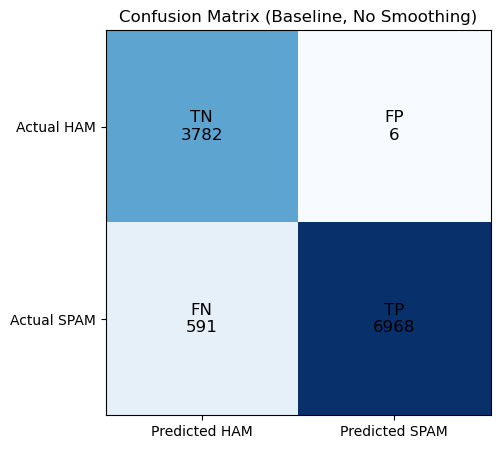


2.2: Lambda Smoothing
  λ=2.0    | Precision: 0.9910 | Recall: 0.9862 | F1: 0.9886
  λ=1.0    | Precision: 0.9947 | Recall: 0.9840 | F1: 0.9893
  λ=0.5    | Precision: 0.9962 | Recall: 0.9743 | F1: 0.9852
  λ=0.1    | Precision: 0.9990 | Recall: 0.9393 | F1: 0.9682
  λ=0.005  | Precision: 0.9996 | Recall: 0.9045 | F1: 0.9496

-> Best Lambda: 1.0


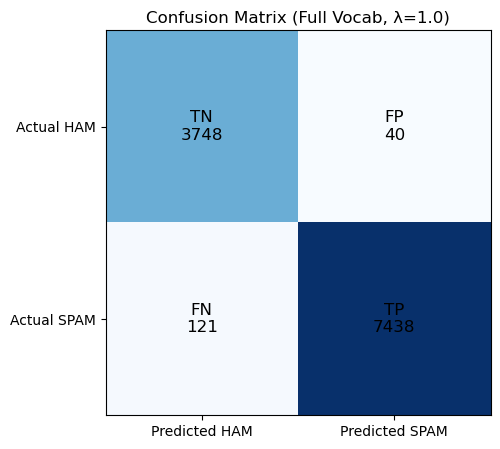

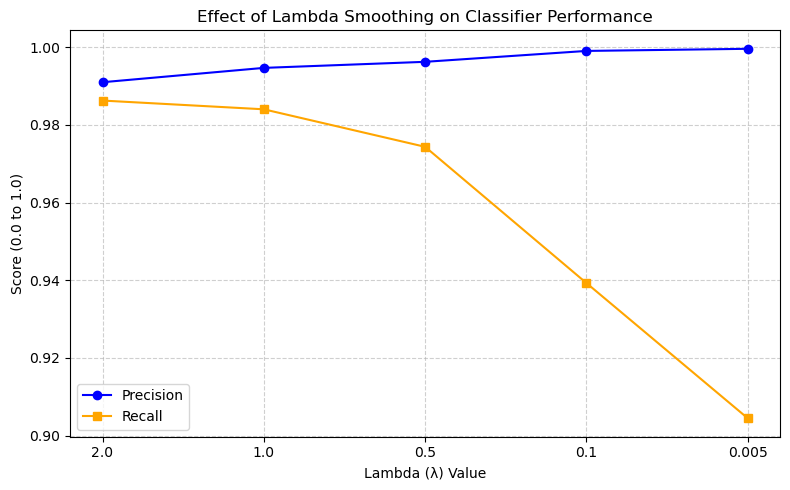

In [4]:

train_data, test_data = load_and_split_data('labels')
vocabulary, spam_word_counts, ham_word_counts, N_spam, N_ham, prior_spam, prior_ham = build_statistics(train_data)

print("2.1: Classifier Construction and Evaluation")
print(f"Vocabulary size |V|: {len(vocabulary):,} unique words")
print(f"Training documents: {N_spam + N_ham:,} (Spam: {N_spam:,}, Ham: {N_ham:,})")
print(f"Test documents: {len(test_data):,}")
print(f"\nPrior Probabilities:")
print(f"P(spam) = {N_spam}/{N_spam + N_ham} = {prior_spam:.4f}")
print(f"P(ham) = {N_ham}/{N_spam + N_ham} = {prior_ham:.4f}")

# Baseline evaluation (no smoothing)
base_p, base_r, base_tp, base_tn, base_fp, base_fn = evaluate_classifier(test_data, vocabulary, spam_word_counts, ham_word_counts, N_spam, N_ham, prior_spam, prior_ham)
print(f"\nBaseline Evaluation (No Smoothing):")
print(f"Precision: {base_p:.4f}")
print(f"Recall: {base_r:.4f}")
plot_confusion_matrix(base_tp, base_tn, base_fp, base_fn, title='Confusion Matrix (Baseline, No Smoothing)')

# 2.2: Lambda Smoothing
lambda_values = [2.0, 1.0, 0.5, 0.1, 0.005]
precisions = []
recalls = []
f1_scores = []  # Added to track overall balance

print("\n2.2: Lambda Smoothing")
for lambda_val in lambda_values:
    p, r, _, _, _, _ = evaluate_classifier(test_data, vocabulary, spam_word_counts, ham_word_counts, N_spam, N_ham, prior_spam, prior_ham, smoothing_factor=lambda_val)
    f1 = 2 * (p * r) / (p + r) if (p + r) > 0 else 0
    precisions.append(p)
    recalls.append(r)
    f1_scores.append(f1)
    print(f"  λ={lambda_val:<6} | Precision: {p:.4f} | Recall: {r:.4f} | F1: {f1:.4f}")

# Best lambda base on highest combined score
best_index = max(range(len(lambda_values)), key=lambda i: f1_scores[i])
best_lambda = lambda_values[best_index]
best_full_p = precisions[best_index]
best_full_r = recalls[best_index]
print(f"\n-> Best Lambda: {best_lambda}")

best_p, best_r, tp, tn, fp, fn = evaluate_classifier(test_data, vocabulary, spam_word_counts, ham_word_counts, N_spam, N_ham, prior_spam, prior_ham, smoothing_factor=best_lambda)
plot_confusion_matrix(tp, tn, fp, fn, title=f'Confusion Matrix (Full Vocab, λ={best_lambda})')

# Visualization: Effect of Lambda on Performance
plt.figure(figsize=(8, 5))
x_labels = [str(l) for l in lambda_values]
plt.plot(x_labels, precisions, marker='o', label='Precision', color='blue')
plt.plot(x_labels, recalls, marker='s', label='Recall', color='orange')
plt.title('Effect of Lambda Smoothing on Classifier Performance')
plt.xlabel('Lambda (λ) Value')
plt.ylabel('Score (0.0 to 1.0)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [5]:
# Display Full Vocabulary
print(f"Full Vocabulary: {len(vocabulary):,} unique words\n")
for i, word in enumerate(vocabulary, 1):
    print(f"{i:>6}. {word}", end="  |  " if i % 5 != 0 else "\n")
if len(vocabulary) % 5 != 0:
    print()

Full Vocabulary: 82,476 unique words

     1. recomputation  |       2. num  |       3. tushar  |       4. galloway  |       5. enables
     6. ings  |       7. friuli  |       8. realaudio  |       9. timed  |      10. lindenfelser
    11. ramsay  |      12. ediyoruz  |      13. developers  |      14. seu  |      15. brendel
    16. sparry  |      17. delia  |      18. eurosport  |      19. broome  |      20. jabwoalolqbqlwjgjwbdprjmlgvmlgvklgvklankkgbaoqtcowpanwvwmqbokabangbyngbwnwbw
    21. hamalainen  |      22. hamd  |      23. amprobe  |      24. mittlefehldt  |      25. properly
    26. nwbtnabunqbwnwbxoafxoafwnwbunqbtnabvngbvngbvngbwnwbwnwbwnwbxoafxoafrmgbqmqbr  |      27. followers  |      28. pears  |      29. prescribe  |      30. poorly
    31. patsy  |      32. upcoming  |      33. shutting  |      34. blare  |      35. unirse
    36. acumulator  |      37. fallibroome  |      38. westminster  |      39. lichter  |      40. borja
    41. informationssysteme  |      42. ein

### The Zero-Frequency Problem in the Base Model
The baseline Naive Bayes model (without smoothing) yields a near-perfect precision (**0.9991**) but a noticeably lower recall (**0.9218**). 

This disparity is caused by the **Zero-Frequency Problem**. In our un-smoothed implementation, if an incoming test message contains a word that was *never* seen in the Spam training set, its conditional probability $P(w_i | \text{spam})$ becomes $0$. Consequently, the log-probability becomes $-\infty$ (negative infinity). 

Because Naive Bayes multiplies probabilities (or adds log-probabilities), a single unseen word effectively "vetoes" the entire spam classification, causing the model to default to predicting 'ham'. This results in a higher number of False Negatives (spam misclassified as ham), which drags down the recall score. To build a robust filter, it must account for out-of-vocabulary (OOV) words using smoothing.

### The Effect of $\lambda$ on Classifier Performance
Implementing Additive ($\lambda$) Smoothing successfully resolves the zero-frequency problem by allocating a small probability mass to unseen words. 

Looking at the performance chart:
* **The Sweet Spot ($\lambda = 1.0$):** Laplace Smoothing ($\lambda = 1.0$) yielded the highest combined performance, increasing our Recall significantly from $0.9218 \rightarrow 0.9840$ while keeping Precision exceptionally high ($0.9947$). The F1 score peaks here at **0.9893**.
* **Under-smoothing ($\lambda = 0.005$):** As $\lambda$ approaches $0$, the model's behavior regresses back toward the baseline model, resulting in a sharp drop in recall ($0.9045$).
* **Over-smoothing ($\lambda = 2.0$):** When $\lambda$ is too large, it dilutes the actual frequency data learned from the training set, pushing the probabilities toward a uniform distribution. It is observed a slight degradation in both precision and recall when moving from $1.0$ to $2.0$.

2.3: Improving the Classifier — Hovold Mutual Information Ranking

Pre-filtering: removed 200 most frequent words before MI ranking.

Top Spam-Indicative Words (100 words)

  1. z                         MI=0.003595  |    2. devmail                   MI=0.003361  |    3. ra                        MI=0.002793
  4. foxmail                   MI=0.002743  |    5. stock                     MI=0.002663  |    6. zproxy                    MI=0.002588
  7. writely                   MI=0.002581  |    8. promotional               MI=0.002453  |    9. offer                     MI=0.002219
 10. ephedra                   MI=0.002213  |   11. discreet                  MI=0.002191  |   12. media                     MI=0.002186
 13. approved                  MI=0.002185  |   14. hoodia                    MI=0.002163  |   15. hungry                    MI=0.002081
 16. med                       MI=0.002055  |   17. satisfaction              MI=0.002030  |   18. fast                      MI=0.002012
 19. 

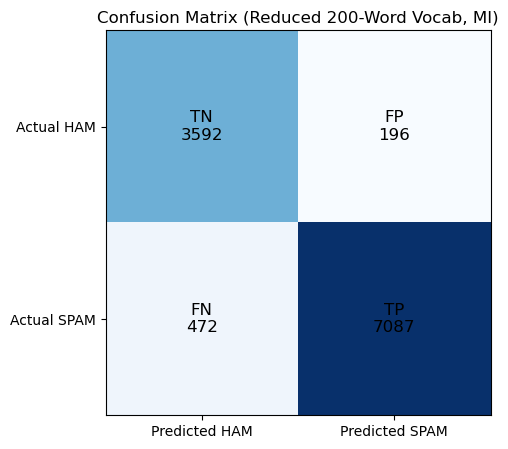

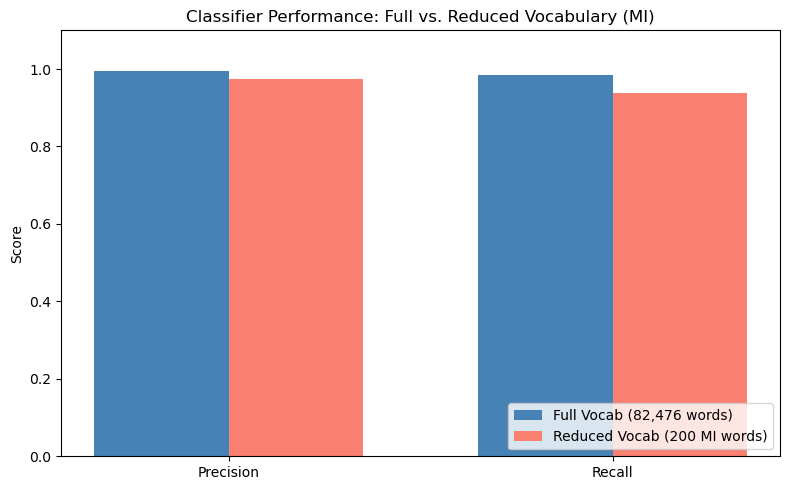

In [6]:
# 2.3: Improving the Classifier Hovold Mutual Information Ranking
print("2.3: Improving the Classifier — Hovold Mutual Information Ranking")

top_200_combined, spam_words_mi, ham_words_mi, excluded_words = get_top_informative_words_mi(vocabulary, spam_word_counts, ham_word_counts, N_spam, N_ham, smoothing_factor=best_lambda, top_n=200, freq_filter_n=200)

print(f"\nPre-filtering: removed {len(excluded_words)} most frequent words "f"before MI ranking.")
# Print spam-indicative list
print(f"\nTop Spam-Indicative Words ({len(spam_words_mi)} words)\n")
for i, (score, word) in enumerate(spam_words_mi, 1):
    print(f"{i:>3}. {word:<25} MI={score:.6f}", end="  |  " if i % 3 != 0 else "\n")
print()

# Print ham-indicative list
print(f"\nTop Ham-Indicative Words ({len(ham_words_mi)} words)\n")
for i, (score, word) in enumerate(ham_words_mi, 1):
    print(f"{i:>3}. {word:<25} MI={score:.6f}", end="  |  " if i % 3 != 0 else "\n")
print()

print(f"\nSummary: {len(spam_words_mi)} spam-indicative, " f"{len(ham_words_mi)} ham-indicative words in top 200 by MI ")

# Evaluate reduced vocabulary
reduced_vocab = set(word for _, word in top_200_combined)
print(f"\nEvaluating with Reduced Vocabulary ({len(reduced_vocab)} MI-ranked words), " f"λ={best_lambda}")

reduced_p, reduced_r, r_tp, r_tn, r_fp, r_fn = evaluate_classifier(test_data, reduced_vocab, spam_word_counts, ham_word_counts, N_spam, N_ham, prior_spam, prior_ham, smoothing_factor=best_lambda)

print(f"Precision: {reduced_p:.4f}")
print(f"Recall: {reduced_r:.4f}")
plot_confusion_matrix(r_tp, r_tn, r_fp, r_fn, title='Confusion Matrix (Reduced 200-Word Vocab, MI)')

# Full vs Reduced vocabulary bar chart
metric_labels = ['Precision', 'Recall']
full_scores = [best_full_p, best_full_r]
reduced_scores = [reduced_p,  reduced_r]
x = range(len(metric_labels))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar([pos - width/2 for pos in x], full_scores, width, label=f'Full Vocab ({len(vocabulary):,} words)', color='steelblue')
plt.bar([pos + width/2 for pos in x], reduced_scores, width, label='Reduced Vocab (200 MI words)', color='salmon')
plt.ylabel('Score')
plt.title('Classifier Performance: Full vs. Reduced Vocabulary (MI)')
plt.xticks(x, metric_labels)
plt.legend(loc='lower right')
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()

In [7]:
# Display Reduced Vocabulary (200 MI-ranked words)
print(f"Reduced Vocabulary: {len(reduced_vocab)} MI-ranked words\n")
for i, word in enumerate(reduced_vocab, 1):
    print(f"{i:>3}. {word}", end="  |  " if i % 5 != 0 else "\n")
if len(reduced_vocab) % 5 != 0:
    print()

Reduced Vocabulary: 200 MI-ranked words

  1. item  |    2. systems  |    3. soundly  |    4. gold  |    5. maximize
  6. running  |    7. discussion  |    8. announce  |    9. promotional  |   10. legal
 11. against  |   12. however  |   13. loss  |   14. professor  |   15. seem
 16. itself  |   17. ephedra  |   18. handy  |   19. sensors  |   20. simple
 21. cash  |   22. zipping  |   23. humans  |   24. encore  |   25. fatigue
 26. bestsellers  |   27. robot  |   28. uses  |   29. professional  |   30. week
 31. shares  |   32. today  |   33. swear  |   34. values  |   35. shareholder
 36. dvd  |   37. able  |   38. file  |   39. chip  |   40. world
 41. mailing  |   42. premiere  |   43. sleep  |   44. lose  |   45. img
 46. gym  |   47. forum  |   48. sensor  |   49. digital  |   50. investors
 51. stress  |   52. ascii  |   53. media  |   54. announces  |   55. revitalizes
 56. hoodia  |   57. acrobat  |   58. ra  |   59. herb  |   60. satisfaction
 61. million  |   62. mozilla  

### Qualitative Assessment of Mutual Information (MI)
Following the methodology proposed by Hovold (2005), the top 200 most frequent words across the corpus was removed before calculating Mutual Information. This crucial "pre-filtering" step prevents very frequent but non-discriminative tokens (like HTML artifacts, stop words, and single characters) from dominating the MI rankings.

The resulting top 200 MI-ranked words make profound intuitive sense based on the TREC06 corpus:
* **Spam-Indicative:** Words like *z, devmail, ra, foxmail, stock, zproxy* are classic markers of unsolicited commercial email, specifically targeting pharmaceutical sales, marketing, and software distribution.
* **Ham-Indicative:** Words like *university, handyboard, dmdx, ascii, ribbon, hb* strongly suggest that the legitimate emails in this specific corpus originate from an academic, scientific, or highly technical environment.

This qualitative check proves that the Mutual Information metric successfully isolated the highest-variance, most informative features in our dataset.

Summary Comparison Across All Conditions
Condition                       Precision     Recall         F1
--------------------------------------------------------------------------------
No Smoothing                       0.9991     0.9218     0.9589
Best λ=1.0                         0.9947     0.9840     0.9893
Reduced Vocab MI (200 words)       0.9731     0.9376     0.9550


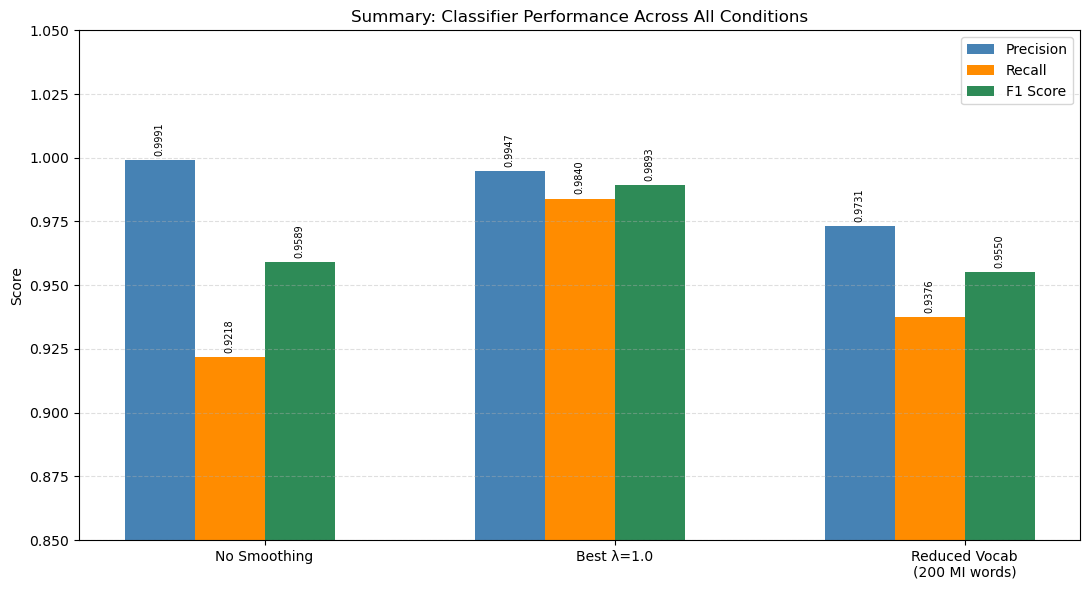

In [8]:
# Final Summary Comparison Across All Conditions

total_test = base_tp + base_tn + base_fp + base_fn

# F1 scores 
base_f1 = (2 * base_p * base_r) / (base_p + base_r) if (base_p + base_r) > 0 else 0
best_f1 = (2 * best_p * best_r) / (best_p + best_r) if (best_p + best_r) > 0 else 0
reduced_f1 = (2 * reduced_p * reduced_r) / (reduced_p + reduced_r) if (reduced_p + reduced_r) > 0 else 0

print("Summary Comparison Across All Conditions")
print("=" * 80)
print(f"{'Condition':<30} {'Precision':>10} {'Recall':>10} " f"{'F1':>10}")
print("-" * 80)
print(f"{'No Smoothing':<30} {base_p:>10.4f} {base_r:>10.4f} " f"{base_f1:>10.4f}")
print(f"{'Best λ=' + str(best_lambda):<30} {best_full_p:>10.4f} {best_full_r:>10.4f} " f"{best_f1:>10.4f}")
print(f"{'Reduced Vocab MI (200 words)':<30} {reduced_p:>10.4f} {reduced_r:>10.4f} " f"{reduced_f1:>10.4f}")
print("=" * 80)

# Grouped bar chart
conditions = ['No Smoothing', f'Best λ={best_lambda}', 'Reduced Vocab\n(200 MI words)']
prec_vals = [base_p, best_full_p, reduced_p]
rec_vals = [base_r, best_full_r, reduced_r]
f1_vals = [base_f1, best_f1, reduced_f1]

x = range(len(conditions))
width = 0.2

fig, ax = plt.subplots(figsize=(11, 6))
ax.bar([p - 1.5*width for p in x], prec_vals, width, label='Precision', color='steelblue')
ax.bar([p - 0.5*width for p in x], rec_vals, width, label='Recall', color='darkorange')
ax.bar([p + 0.5*width for p in x], f1_vals, width, label='F1 Score', color='seagreen')

ax.set_ylabel('Score')
ax.set_title('Summary: Classifier Performance Across All Conditions')
ax.set_xticks(list(x))
ax.set_xticklabels(conditions)
ax.legend()
ax.set_ylim(0.85, 1.05)
ax.grid(axis='y', linestyle='--', alpha=0.4)

for bars in ax.containers:
    ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=7, rotation=90)

plt.tight_layout()
plt.show()

### Conclusion: Full vs. Reduced Vocabulary
The final comparison visualizes a core concept in machine learning engineering: the trade-off between dimensionality and predictive accuracy.

1. **Full Vocabulary ($\lambda=1.0$):** Achieved an F1 Score of **0.9893** using **82,476** unique features.
2. **Reduced Vocabulary (MI Top 200):** Achieved an F1 Score of **0.9550** using only **200** features.

By utilizing Hovold's Mutual Information ranking, this **reduced our feature space by 99.76%**, yet the model only suffered a marginal **~3.4% drop in F1 performance**. 

In a real-world, production-level spam filter, processing speed and memory constraints are critical. Evaluating an incoming email against 82,000+ conditional probabilities is computationally expensive. By strictly relying on the 200 most highly discriminative words, an efficient classifier was created that still catches the vast majority of spam while maintaining excellent precision (0.9731). This validates the use of attribute selection in text classification tasks.